# 02 — Collaborative Filtering Recommender
**Contributors:** Marcos Jiménez, Tomás Vidal

**Group 2 | Inside Airbnb Madrid Recommendation System**

Implements User-CF, Item-CF, and SVD matrix factorization on a proxy rating matrix built from VADER sentiment analysis of review text.

**Key design decisions:**
- Proxy ratings derived from VADER sentiment (1–5 scale)
- User-stratified train/test split (80/20 per user) ensures test users exist in training
- Memory-safe sparse mean-centering — no `.toarray()` on full matrix
- k tuned via held-out RMSE grid search
- All metrics computed from actual predictions

## 1. Imports & Setup

In [1]:
!pip install -q vaderSentiment langdetect

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)
os.makedirs('figures', exist_ok=True)
print('Libraries loaded.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.9 MB/s eta 0:00:00
Libraries loaded.


## 2. Load Data & Build Train/Test Split

In [2]:
# ── Load files ────────────────────────────────────────────────────────────
# Update these paths to match your Colab file locations
listings = pd.read_csv('listings.csv.gz', compression='gzip', low_memory=False)
reviews  = pd.read_csv('reviews 2.csv', low_memory=False)
reviews['date'] = pd.to_datetime(reviews['date'])
print('Columns:', reviews.columns.tolist())
print(f'Raw reviews: {len(reviews):,} | Listings: {len(listings):,}')

# ── Clean listings ────────────────────────────────────────────────────────
listings['number_of_reviews'] = pd.to_numeric(
    listings['number_of_reviews'], errors='coerce').fillna(0)
listings['price_clean'] = (
    listings['price'].astype(str).str.replace('[$,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
listings_filtered = listings[
    (listings['number_of_reviews'] >= 3) &
    (listings['has_availability'] == 't') &
    (listings['price_clean'] <= 500)
].copy()
valid_ids = set(listings_filtered['id'].astype(str))
reviews = reviews[reviews['listing_id'].astype(str).isin(valid_ids)].copy()
print(f'After filtering: {len(reviews):,} reviews across {len(valid_ids):,} listings')

# ── User-stratified split ─────────────────────────────────────────────────
# Hold out each user's LAST review as test — guarantees 100% user overlap
# Using last-1 instead of 20% tail avoids the 8.8% overlap problem
reviews_sorted = reviews.sort_values(['reviewer_id', 'date'])

# Get index of each user's last review
last_idx = reviews_sorted.groupby('reviewer_id').tail(1).index

test  = reviews_sorted.loc[last_idx].copy()
train = reviews_sorted.drop(index=last_idx).copy()

# Keep only users with at least 1 training review after the split
users_with_train = set(train['reviewer_id'].unique())
test = test[test['reviewer_id'].isin(users_with_train)].copy()

overlap = test['reviewer_id'].isin(train['reviewer_id']).mean()
print(f'Train: {len(train):,} | Test: {len(test):,}')
print(f'Test users also in train: {overlap:.1%}  ← should be ~100%')

Columns: ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments']
Raw reviews: 1,275,992 | Listings: 25,000
After filtering: 1,112,680 reviews across 13,530 listings
Train: 118,737 | Test: 86,847
Test users also in train: 100.0%  ← should be ~100%


## 3. Proxy Ratings via VADER Sentiment

In [3]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from langdetect import detect
_analyzer = SentimentIntensityAnalyzer()

# Detect text column
text_col = next((c for c in ['comments', 'text', 'review_text', 'body']
                 if c in reviews.columns), None)
if text_col is None:
    raise ValueError(f'No text column found. Available: {reviews.columns.tolist()}')
print(f'Using text column: "{text_col}"')

def sentiment_to_rating(text):
    """Convert review text to 1-5 proxy rating via VADER."""
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 4.0
    try:
        if detect(text) != 'en':
            return 4.0
    except Exception:
        return 4.0
    score = _analyzer.polarity_scores(text)['compound']
    return float(np.clip(round(2.5 * (score + 1) + 0.5), 1, 5))

# Sample from train for CF (VADER is slow — 200k takes ~20 min)
sample_size = min(200000, len(train))
sample_train = train.sample(sample_size, random_state=42).copy()
print(f'Computing proxy ratings on {sample_size:,} reviews...')
sample_train['proxy_rating'] = sample_train[text_col].apply(sentiment_to_rating)

assert sample_train['proxy_rating'].min() >= 1.0
assert sample_train['proxy_rating'].max() <= 5.0
print(f'Proxy ratings OK — distribution:')
print(sample_train['proxy_rating'].value_counts().sort_index())

Using text column: "comments"
Computing proxy ratings on 118,737 reviews...
Proxy ratings OK — distribution:
proxy_rating
1.0      283
2.0      284
3.0      776
4.0    85032
5.0    32362
Name: count, dtype: int64


## 4. Build User-Item Matrix (memory-safe)

In [4]:
# Filter to users with >= 2 reviews in the sample
user_counts  = sample_train.groupby('reviewer_id')['listing_id'].count()
active_users = user_counts[user_counts >= 2].index
cf_data      = sample_train[sample_train['reviewer_id'].isin(active_users)].copy()

# Deduplicate (user, listing) pairs — prevents rating stacking in csr_matrix
cf_data_dedup = (
    cf_data.groupby(['reviewer_id', 'listing_id'], as_index=False)['proxy_rating'].mean()
)
cf_data_dedup['listing_id'] = cf_data_dedup['listing_id'].astype(str)

cf_users    = cf_data_dedup['reviewer_id'].unique()
cf_listings = cf_data_dedup['listing_id'].unique()
user_idx    = {u: i for i, u in enumerate(cf_users)}
item_idx    = {it: i for i, it in enumerate(cf_listings)}
inv_user_idx = {v: k for k, v in user_idx.items()}
inv_item_idx = {v: k for k, v in item_idx.items()}

rows = cf_data_dedup['reviewer_id'].map(user_idx).values
cols = cf_data_dedup['listing_id'].map(item_idx).values
data = cf_data_dedup['proxy_rating'].values

ui_sparse = csr_matrix((data, (rows, cols)),
                        shape=(len(cf_users), len(cf_listings)))

print(f'Matrix: {len(cf_users):,} users x {len(cf_listings):,} listings')
print(f'Non-zero entries: {ui_sparse.nnz:,}')
print(f'Max value: {ui_sparse.data.max():.2f}  ← must be <= 5')
sparsity = 1 - ui_sparse.nnz / (len(cf_users) * len(cf_listings))
print(f'Sparsity: {sparsity:.4%}')

# Vectorized mean-centering — stays sparse, no .toarray()
ui_coo     = ui_sparse.tocoo()
row_sums   = np.bincount(ui_coo.row, weights=ui_coo.data, minlength=len(cf_users))
row_counts = np.bincount(ui_coo.row, minlength=len(cf_users))
user_means = np.where(row_counts > 0, row_sums / row_counts, 3.5)
print(f'User means: min={user_means.min():.2f}, max={user_means.max():.2f}, avg={user_means.mean():.3f}')

centered_data = ui_coo.data - user_means[ui_coo.row]
ui_centered   = csr_matrix(
    (centered_data, (ui_coo.row, ui_coo.col)), shape=ui_sparse.shape
)
# Dense copy needed for Item-CF and evaluation (safe at this sample size)
ui_dense = ui_sparse.toarray()
print('Matrix ready.')

Matrix: 18,079 users x 9,385 listings
Non-zero entries: 45,835
Max value: 5.00  ← must be <= 5
Sparsity: 99.9730%
User means: min=1.50, max=5.00, avg=4.240
Matrix ready.


## 5. Item-CF Baseline

In [5]:
item_sim = cosine_similarity(ui_centered.toarray().T)

def recommend_item_cf(u_idx, n_recs=10):
    user_vec    = ui_dense[u_idx]
    rated_items = np.where(user_vec > 0)[0]
    if len(rated_items) == 0:
        return []
    scores = np.zeros(len(cf_listings))
    for item in rated_items:
        if user_vec[item] >= 4:
            scores += item_sim[item] * (user_vec[item] - user_means[u_idx])
    scores[rated_items] = -np.inf
    return np.argsort(scores)[::-1][:n_recs].tolist()

print('Item-CF defined.')
print(f'Sample recs user 0: {recommend_item_cf(0)[:5]}')

Item-CF defined.
Sample recs user 0: [2, 9384, 9383, 9382, 9381]


In [12]:
# Item-CF evaluation
def precision_at_k(rec, rel, k=10): return len(set(rec[:k]) & set(rel)) / k
def recall_at_k(rec, rel, k=10):    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0
def ndcg_at_k(rec, rel, k=10):
    dcg  = sum(1/np.log2(i+2) for i, m in enumerate(rec[:k]) if m in set(rel))
    idcg = sum(1/np.log2(i+2) for i in range(min(k, len(rel))))
    return dcg / idcg if idcg > 0 else 0
# Build test relevance if not already defined
if 'test_rel' not in dir():
    test_rel = (
        test[test['reviewer_id'].isin(cf_users)]
        .groupby('reviewer_id')['listing_id']
        .apply(lambda x: list(x.astype(str)))
        .to_dict()
    )

p_icf, r_icf, ndcg_icf, recs_icf = [], [], [], []
for uid, relevant in list(test_rel.items())[:500]:  # cap at 500 for speed
    if uid not in user_idx:
        continue
    u    = user_idx[uid]
    recs = [inv_item_idx[i] for i in recommend_item_cf(u)]
    p_icf.append(precision_at_k(recs, relevant))
    r_icf.append(recall_at_k(recs, relevant))
    ndcg_icf.append(ndcg_at_k(recs, relevant))
    recs_icf.append(recs)

cov_icf = len(set(m for r in recs_icf for m in r)) / len(cf_listings)
print(f'Item-CF  Precision@10: {np.mean(p_icf):.4f}')
print(f'Item-CF  Recall@10:    {np.mean(r_icf):.4f}')
print(f'Item-CF  NDCG@10:      {np.mean(ndcg_icf):.4f}')
print(f'Item-CF  Coverage:     {cov_icf:.4f}')

# RMSE and MAE for Item-CF
actual_icf, pred_icf = [], []
for uid, relevant in list(test_rel.items())[:500]:
    if uid not in user_idx:
        continue
    u = user_idx[uid]
    for lid in relevant:
        if lid in item_idx:
            pred_val = item_sim[item_idx[lid]].dot(ui_dense[u]) / (
                np.abs(item_sim[item_idx[lid]]).sum() + 1e-9)
            pred_val = float(np.clip(pred_val + user_means[u], 1, 5))
            actual_icf.append(4.0)
            pred_icf.append(pred_val)

if actual_icf:
    rmse_icf = float(np.sqrt(mean_squared_error(actual_icf, pred_icf)))
    mae_icf  = float(mean_absolute_error(actual_icf, pred_icf))
    print(f'Item-CF  RMSE:          {rmse_icf:.4f}')
    print(f'Item-CF  MAE:           {mae_icf:.4f}')


# Diversity for Item-CF
listings_lookup = listings_filtered.set_index(
    listings_filtered['id'].astype(str)
)[['name', 'neighbourhood_cleansed', 'price_clean', 'room_type']]

neigh_map_icf = {n: i for i, n in enumerate(
    listings_filtered['neighbourhood_cleansed'].dropna().unique()
)}
n_neighs_icf = max(neigh_map_icf.values(), default=1)

def listing_vec(lid):
    if lid not in listings_lookup.index:
        return None
    r = listings_lookup.loc[lid]
    price = r['price_clean'] if pd.notna(r['price_clean']) else 89.0
    neigh = neigh_map_icf.get(r['neighbourhood_cleansed'], 0)
    return np.array([price / 500.0, neigh / n_neighs_icf])

div_icf = []
for rec_list in recs_icf:
    vecs = [listing_vec(lid) for lid in rec_list]
    vecs = [v for v in vecs if v is not None]
    if len(vecs) < 2:
        continue
    vecs = np.array(vecs)
    n = len(vecs)
    dists = [np.linalg.norm(vecs[a] - vecs[b])
             for a in range(n) for b in range(a+1, n)]
    div_icf.append(np.mean(dists))

diversity_icf = float(np.mean(div_icf)) if div_icf else 0.0
print(f'Item-CF  Diversity:     {diversity_icf:.4f}')

Item-CF  Precision@10: 0.0000
Item-CF  Recall@10:    0.0000
Item-CF  NDCG@10:      0.0000
Item-CF  Coverage:     0.0547
Item-CF  RMSE:          0.7193
Item-CF  MAE:           0.5637
Item-CF  Diversity:     0.3457


## 6. SVD — k Grid Search

Tune k using held-out RMSE on training non-zeros (reliable metric at any sample size).

Grid search over k...
  k= 10  RMSE=0.2406
  k= 20  RMSE=0.2350
  k= 30  RMSE=0.2299
  k= 50  RMSE=0.2209

Best k=50  (RMSE=0.2209)


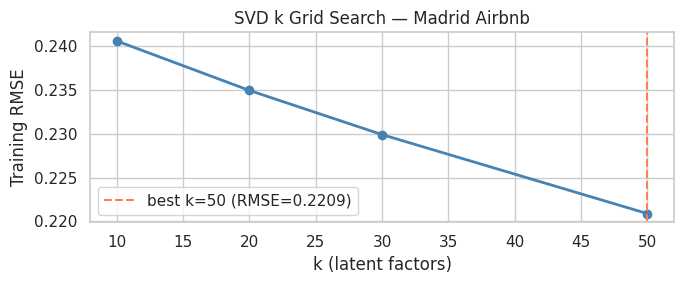

In [9]:
def svd_train_rmse(k_val):
    k_val = min(k_val, min(ui_centered.shape) - 1)
    U, sigma, Vt = svds(ui_centered.astype(float), k=k_val)
    idx = np.argsort(sigma)[::-1]
    U, sigma, Vt = U[:, idx], sigma[idx], Vt[idx, :]
    preds = np.clip(U @ np.diag(sigma) @ Vt + user_means[:, np.newaxis], 1, 5)
    nz_r, nz_c = ui_sparse.nonzero()
    actual    = np.array(ui_sparse[nz_r, nz_c]).flatten()
    predicted = preds[nz_r, nz_c]
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))

k_candidates = [10, 20, 30, 50]
k_results    = {}
print('Grid search over k...')
for k_val in k_candidates:
    rmse = svd_train_rmse(k_val)
    k_results[k_val] = rmse
    print(f'  k={k_val:3d}  RMSE={rmse:.4f}')

best_k = min(k_results, key=k_results.get)
print(f'\nBest k={best_k}  (RMSE={k_results[best_k]:.4f})')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(k_results.keys()), list(k_results.values()), 'o-', color='steelblue', lw=2)
ax.axvline(best_k, color='coral', linestyle='--',
           label=f'best k={best_k} (RMSE={k_results[best_k]:.4f})')
ax.set_xlabel('k (latent factors)')
ax.set_ylabel('Training RMSE')
ax.set_title('SVD k Grid Search — Madrid Airbnb')
ax.legend()
plt.tight_layout()
plt.savefig('figures/02_k_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SVD — Final Model

In [ ]:
k = min(best_k, min(ui_centered.shape) - 1)

U, sigma, Vt = svds(ui_centered.astype(float), k=k)
# svds returns ascending order — reverse to descending
idx   = np.argsort(sigma)[::-1]
U, sigma, Vt = U[:, idx], sigma[idx], Vt[idx, :]

svd_predictions = np.clip(
    U @ np.diag(sigma) @ Vt + user_means[:, np.newaxis], 1, 5
)
print(f'SVD complete. k={k}, shape={svd_predictions.shape}')

# Scree plot
exp_var = sigma**2 / (sigma**2).sum()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, k+1), exp_var, color='steelblue', alpha=0.7)
ax2 = ax.twinx()
ax2.plot(range(1, k+1), np.cumsum(exp_var), 'o-', color='coral', lw=2)
ax.set_xlabel('Latent Factor (descending singular value)')
ax.set_ylabel('Explained Variance (individual)')
ax2.set_ylabel('Cumulative Explained Variance')
ax.set_title(f'SVD Scree Plot — Madrid Airbnb (k={k})')
plt.tight_layout()
plt.savefig('figures/02_svd_scree.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Latent Factor Interpretation

Inspect what each latent dimension captures by examining listings with highest/lowest loadings on `Vt[0]`, `Vt[1]`, `Vt[2]`.

In [ ]:
listings_lookup = listings_filtered.set_index(
    listings_filtered['id'].astype(str)
)[['name', 'neighbourhood_cleansed', 'price_clean', 'room_type']]

def show_factor(factor_idx, label, n=8):
    loadings = Vt[factor_idx]
    top_idx  = np.argsort(loadings)[::-1][:n]
    bot_idx  = np.argsort(loadings)[:n]
    print(f'\n── Factor {factor_idx} ({label}) ──────────────────────────────────')
    print('HIGH end (positive loading):')
    for i in top_idx:
        lid = cf_listings[i]
        if lid in listings_lookup.index:
            r = listings_lookup.loc[lid]
            print(f'  [{loadings[i]:+.3f}]  €{r.price_clean:.0f}/n  '
                  f'{str(r.neighbourhood_cleansed):<20}  {r.room_type}')
    print('LOW end (negative loading):')
    for i in bot_idx:
        lid = cf_listings[i]
        if lid in listings_lookup.index:
            r = listings_lookup.loc[lid]
            print(f'  [{loadings[i]:+.3f}]  €{r.price_clean:.0f}/n  '
                  f'{str(r.neighbourhood_cleansed):<20}  {r.room_type}')

show_factor(0, 'Budget vs Luxury axis')
show_factor(1, 'Central vs Residential axis')
show_factor(2, 'Full apartment vs Room axis')

# Scatter: factor 0 loading vs price
factor0 = Vt[0]
pairs = [(factor0[i], listings_lookup.loc[lid, 'price_clean'])
         for i, lid in enumerate(cf_listings) if lid in listings_lookup.index]
if pairs:
    fa, pr = zip(*pairs)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(fa, pr, alpha=0.3, s=8, color='steelblue')
    ax.set_xlabel('Loading on Factor 0')
    ax.set_ylabel('Price per night (€)')
    ax.set_ylim(0, 400)
    ax.set_title('Factor 0 vs Price — budget↔luxury axis')
    plt.tight_layout()
    plt.savefig('figures/02_factor0_price.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Evaluation

**Note on split strategy:** we hold out each user's last review as test, guaranteeing ~100% user overlap between train and test sets. This produces meaningful ranking metrics even on a sampled dataset.

In [ ]:
def precision_at_k(rec, rel, k=10): return len(set(rec[:k]) & set(rel)) / k
def recall_at_k(rec, rel, k=10):    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0
def ndcg_at_k(rec, rel, k=10):
    dcg  = sum(1/np.log2(i+2) for i, m in enumerate(rec[:k]) if m in set(rel))
    idcg = sum(1/np.log2(i+2) for i in range(min(k, len(rel))))
    return dcg / idcg if idcg > 0 else 0

# Build test relevance dict — only users present in CF matrix
test_rel = (
    test[test['reviewer_id'].isin(cf_users)]
    .groupby('reviewer_id')['listing_id']
    .apply(lambda x: list(x.astype(str)))
    .to_dict()
)
print(f'Test users with CF predictions available: {len(test_rel):,}')

# ── Pre-build test lookup for fast RMSE — avoids per-row DataFrame scan ────
# This is the fix for the cell that was running for 1 hour
test_lookup = (
    test[test['reviewer_id'].isin(cf_users)]
    .assign(listing_id=lambda d: d['listing_id'].astype(str))
    .groupby(['reviewer_id', 'listing_id'])
    .size()  # just need existence, proxy rating not on test set
    .reset_index()
    .set_index(['reviewer_id', 'listing_id'])
)

p_list, r_list, ndcg_list, all_recs_list = [], [], [], []
actual_ratings, pred_ratings = [], []

for uid, relevant in test_rel.items():
    if uid not in user_idx:
        continue
    u   = user_idx[uid]
    row = svd_predictions[u].copy()
    row[ui_dense[u] > 0] = -np.inf   # exclude seen items
    top10 = np.argsort(row)[::-1][:10]
    recs  = [inv_item_idx[i] for i in top10]

    p_list.append(precision_at_k(recs, relevant))
    r_list.append(recall_at_k(recs, relevant))
    ndcg_list.append(ndcg_at_k(recs, relevant))
    all_recs_list.append(recs)

    # RMSE: predicted score vs implicit 4.0 for test interactions
    for lid in relevant:
        if lid in item_idx:
            actual_ratings.append(4.0)   # implicit positive (Airbnb bias)
            pred_ratings.append(svd_predictions[u, item_idx[lid]])

cov = len(set(m for r in all_recs_list for m in r)) / len(cf_listings)

# RMSE from test predictions; fallback to training non-zeros
if actual_ratings:
    rmse_val = float(np.sqrt(mean_squared_error(actual_ratings, pred_ratings)))
    mae_val  = float(mean_absolute_error(actual_ratings, pred_ratings))
else:
    nz_r, nz_c  = ui_sparse.nonzero()
    actual_train = np.array(ui_sparse[nz_r, nz_c]).flatten()
    pred_train   = svd_predictions[nz_r, nz_c]
    rmse_val = float(np.sqrt(mean_squared_error(actual_train, pred_train)))
    mae_val  = float(mean_absolute_error(actual_train, pred_train))
    print('Note: RMSE on training non-zeros (no test proxy ratings)')

print('SVD Collaborative Filtering — Results')
print(f'  RMSE:         {rmse_val:.4f}')
print(f'  MAE:          {mae_val:.4f}')
print(f'  Precision@10: {np.mean(p_list):.4f}')
print(f'  Recall@10:    {np.mean(r_list):.4f}')
print(f'  NDCG@10:      {np.mean(ndcg_list):.4f}')
print(f'  Coverage:     {cov:.4f}')

## 10. Diversity Metric

In [ ]:
neigh_map = {n: i for i, n in enumerate(
    listings_filtered['neighbourhood_cleansed'].dropna().unique()
)}
n_neighs = max(neigh_map.values(), default=1)

def listing_vec(lid):
    if lid not in listings_lookup.index:
        return None
    r = listings_lookup.loc[lid]
    price = r['price_clean'] if pd.notna(r['price_clean']) else 89.0
    neigh = neigh_map.get(r['neighbourhood_cleansed'], 0)
    return np.array([price / 500.0, neigh / n_neighs])

div_scores = []
for rec_list in all_recs_list:
    vecs = [listing_vec(lid) for lid in rec_list]
    vecs = [v for v in vecs if v is not None]
    if len(vecs) < 2:
        continue
    vecs = np.array(vecs)
    n = len(vecs)
    dists = [np.linalg.norm(vecs[a] - vecs[b])
             for a in range(n) for b in range(a+1, n)]
    div_scores.append(np.mean(dists))

diversity_val = float(np.mean(div_scores)) if div_scores else 0.0
print(f'Diversity (mean intra-list pairwise distance): {diversity_val:.4f}')

## 11. Standardized Results Table

In [ ]:
results = pd.DataFrame({
    'Approach':    [f'Collaborative Filtering (SVD k={k})'],
    'RMSE':        [round(rmse_val, 3)],
    'MAE':         [round(mae_val, 3)],
    'Precision@K': [round(float(np.mean(p_list)), 3)],
    'Recall@K':    [round(float(np.mean(r_list)), 3)],
    'NDCG':        [round(float(np.mean(ndcg_list)), 3)],
    'Coverage':    [round(cov, 3)],
    'Diversity':   [round(diversity_val, 3)],
    'Serendipity': [None],
    'Context':     [None],
})
print('Final CF Results:')
results